In [1]:
# input
metal_group_type_input = "../tmp/pred/test_set_pred_metal_group_type.tsv"
metal_type_input = "../tmp/pred/test_set_pred_metal_type.tsv"
# output
metal_type_output = "./fig/confusion_matrix_metal_type.pdf"
metal_group_type_output = "./fig/confusion_matrix_metal_group_type.pdf"

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

In [6]:
df_pred_metal_group_type = pd.read_table(metal_group_type_input) # svm	ankh-base
y_true = list(df_pred_metal_group_type['label'])
y_pred = list(df_pred_metal_group_type['y_pred'])
labels = ["Alkaline metals", "Transition metals", "Fe-S clusters"]

In [ ]:
print(classification_report(y_true, y_pred, target_names=labels, zero_division=0, digits=4))

                   precision    recall  f1-score   support

  Alkaline metals     0.9015    0.8737    0.8874       744
Transition metals     0.9118    0.9345    0.9230      1084
    Fe-S clusters     1.0000    0.9739    0.9868       153

         accuracy                         0.9147      1981
        macro avg     0.9378    0.9273    0.9324      1981
     weighted avg     0.9147    0.9147    0.9145      1981



<Figure size 240x200 with 0 Axes>

<Axes: >

Text(0.5, -2.277777777777782, 'Predicted')

Text(5.722222222222218, 0.5, 'True')

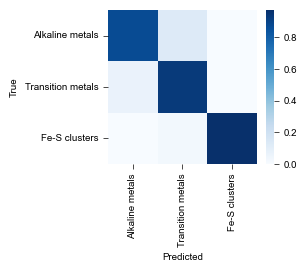

In [ ]:
plt.figure(figsize=(2.4, 2))
cm = confusion_matrix(y_true, y_pred)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(metal_group_type_output, bbox_inches="tight", transparent=True)

In [8]:
df_pred_metal_group_type = pd.read_table(metal_type_input) # nn	esm2-3B
y_true = list(df_pred_metal_group_type['label'])
y_pred = list(df_pred_metal_group_type['y_pred'])

y_true = [2 if label == 0 else 0 if label == 2 else label for label in y_true] # swap mg and zn to make cm more intuitively
y_pred = [2 if label == 0 else 0 if label == 2 else label for label in y_pred]

labels = ["MG", "CA", "ZN", "MN", "FE", "CU", "NI", "CO", "SF4", "FES", "F3S"]

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=labels, zero_division=0, digits=4))

              precision    recall  f1-score   support

          MG     0.4293    0.4702    0.4489       168
          CA     0.8571    0.8125    0.8342       576
          ZN     0.8705    0.7635    0.8135       854
          MN     0.3193    0.5889    0.4141        90
          FE     0.3118    0.5472    0.3973        53
          CU     0.8750    1.0000    0.9333        28
          NI     0.1707    0.1795    0.1750        39
          CO     0.3000    0.3000    0.3000        20
         SF4     0.8981    0.8899    0.8940       109
         FES     0.9032    0.8000    0.8485        35
         F3S     0.5455    0.6667    0.6000         9

    accuracy                         0.7335      1981
   macro avg     0.5891    0.6380    0.6053      1981
weighted avg     0.7704    0.7335    0.7473      1981



<Figure size 240x200 with 0 Axes>

<Axes: >

Text(0.5, -2.277777777777782, 'Predicted')

Text(5.722222222222221, 0.5, 'True')

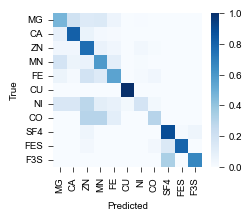

In [10]:
cm = confusion_matrix(y_true, y_pred)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(2.4, 2))
sns.heatmap(cm, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(metal_type_output, bbox_inches="tight", transparent=True)

In [5]:
df_pred_metal_group_type = pd.read_table(metal_group_type_input)
y_true = list(df_pred_metal_group_type['label'])

def assign_group_type(x: int):
    if x in {1, 2}:
        return 0
    elif x in {8, 9, 10}:
        return 2
    else:
        return 1

df_pred_metal_group_type = pd.read_table(metal_type_input)
y_pred = list(df_pred_metal_group_type['y_pred'])
y_pred = [assign_group_type(x) for x in y_pred]

labels = ["Alkaline metals", "Transition metals", "Fe-S clusters"]

print(classification_report(y_true, y_pred, target_names=labels, zero_division=0, digits=4))

                   precision    recall  f1-score   support

  Alkaline metals     0.8603    0.8441    0.8521       744
Transition metals     0.8883    0.9022    0.8952      1084
    Fe-S clusters     0.9733    0.9542    0.9637       153

         accuracy                         0.8844      1981
        macro avg     0.9073    0.9002    0.9037      1981
     weighted avg     0.8843    0.8844    0.8843      1981

